In [138]:
import numpy as np
import random as ran
import math 
import matplotlib.pyplot as plt

In [139]:
J = 1
N = 10000
KB = 1

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (10, 2) + inhomogeneous part.

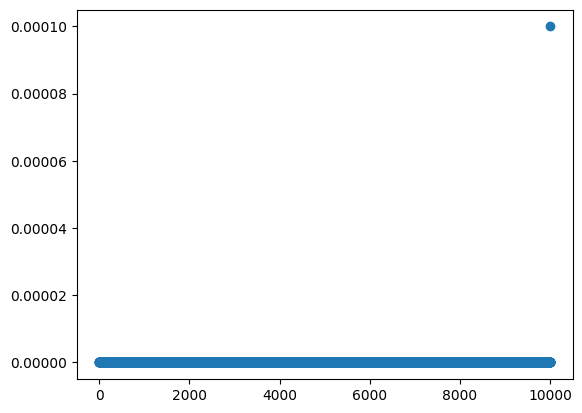

In [ ]:


def DH(S,I,B):
    if(I == 0):
        return -2*J*S[I]*S[I+1]+S[N-1] - 2*B
    elif(I == N - 1):
        return -2*J*S[I]*S[0]+S[I-1] - 2*B
    else:
        return -2*J*S[I]*S[I+1]+S[I-1] - 2*B

def metropolis_step(S,i,T,B):
    STEST = S.copy()

    STEST[i] = -STEST[i]
    p = math.exp(-DH(STEST,i,B)/(KB*T))

    if(p >= ran.random()):
        return STEST
    else:
        return S
    
def esperimento(T,B):
    S = np.zeros(N)
    experiments = np.zeros(N)
    for i in range(N):
        flag = ran.random()

        if flag > 0.5:
            S[i] = 1
        elif flag < 0.5:
            S[i] = -1
        
    for i in range(N):
        S = metropolis_step(S,i,T,B)
    experiments[i] += S[i]
    experiments /= N
    return sum(S)/N

plt.scatter([0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
            [esperimento(0.1,1),esperimento(0.2,1),esperimento(0.3,1),esperimento(0.4,1),esperimento(0.5,1),esperimento(0.6,1),esperimento(0.7,1),esperimento(0.8,1),esperimento(0.9,1),esperimento(1,1)])

